In [1]:
# Import libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Set project path

project_path = r"C:\Users\komet\Downloads\ifrs9-credit-impairment-forecasting"

data_path = os.path.join(project_path, "data")
notebooks_path = os.path.join(project_path, "notebooks")
outputs_path = os.path.join(project_path, "outputs")
figures_path = os.path.join(project_path, "figures")

os.makedirs(data_path, exist_ok=True)
os.makedirs(notebooks_path, exist_ok=True)
os.makedirs(outputs_path, exist_ok=True)
os.makedirs(figures_path, exist_ok=True)

print("Project folders created successfully.")
print(project_path)

Project folders created successfully.
C:\Users\komet\Downloads\ifrs9-credit-impairment-forecasting


In [3]:
# Generate synthetic retail banking loan portfolio

np.random.seed(42)

n = 10000

data = pd.DataFrame({
    "customer_id": np.arange(1, n + 1),
    "age": np.random.randint(21, 70, n),
    "monthly_income": np.random.normal(25000, 8000, n),
    "loan_amount": np.random.normal(120000, 40000, n),
    "loan_term_months": np.random.choice([12, 24, 36, 48, 60, 72], n),
    "interest_rate": np.random.normal(0.18, 0.04, n),
    "credit_score": np.random.normal(620, 80, n),
    "existing_debt": np.random.normal(45000, 20000, n),
    "months_on_book": np.random.randint(1, 72, n),
    "employment_years": np.random.randint(0, 30, n)
})

data.head()

,customer_id,age,monthly_income,loan_amount,loan_term_months,interest_rate,credit_score,existing_debt,months_on_book,employment_years
0,1,59,16771.800115,181933.693144,36,0.173034,662.484974,44040.938934,6,15
1,2,49,17995.937235,150823.268162,72,0.163171,461.411141,56941.843238,69,19
2,3,35,30030.148633,167012.497204,60,0.182963,578.047321,59020.880789,12,3
3,4,63,22141.031229,77703.235015,60,0.145526,677.888400,49154.865188,15,29
4,5,28,38523.204065,201096.935406,24,0.178611,550.001995,80950.972203,67,23


In [4]:
# Clean unrealistic values

data["monthly_income"] = data["monthly_income"].clip(lower=3000)
data["loan_amount"] = data["loan_amount"].clip(lower=5000)
data["interest_rate"] = data["interest_rate"].clip(lower=0.05, upper=0.35)
data["credit_score"] = data["credit_score"].clip(lower=300, upper=850)
data["existing_debt"] = data["existing_debt"].clip(lower=0)

data.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,10000.0,5000.500000,2886.895680,1.00000,2500.750000,5000.500000,7500.250000,10000.000000
age,10000.0,45.151500,14.083223,21.00000,33.000000,45.000000,57.000000,69.000000
monthly_income,10000.0,25006.488998,7979.296683,3000.00000,19556.255698,25036.654309,30406.420435,52348.897435
loan_amount,10000.0,120277.661957,39663.038302,5000.00000,93187.997159,120425.936596,147492.075783,285915.802013
loan_term_months,10000.0,42.055200,20.377637,12.00000,24.000000,48.000000,60.000000,72.000000
interest_rate,10000.0,0.179903,0.039929,0.05000,0.152293,0.179288,0.206843,0.350000
credit_score,10000.0,620.056353,79.784903,321.45083,565.259011,619.812798,674.431003,850.000000
existing_debt,10000.0,45223.430978,20042.918882,0.00000,31593.836087,45432.299629,58617.450061,113878.515200
months_on_book,10000.0,35.908800,20.527368,1.00000,18.000000,36.000000,54.000000,71.000000
employment_years,10000.0,14.474700,8.649719,0.00000,7.000000,14.000000,22.000000,29.000000


In [5]:
# Create credit-risk features

data["debt_to_income"] = data["existing_debt"] / (data["monthly_income"] * 12)
data["loan_to_income"] = data["loan_amount"] / (data["monthly_income"] * 12)
data["instalment_estimate"] = data["loan_amount"] / data["loan_term_months"]
data["instalment_to_income"] = data["instalment_estimate"] / data["monthly_income"]

data[[
    "customer_id",
    "monthly_income",
    "loan_amount",
    "existing_debt",
    "debt_to_income",
    "loan_to_income",
    "instalment_to_income"
]].head()

,customer_id,monthly_income,loan_amount,existing_debt,debt_to_income,loan_to_income,instalment_to_income
0,1,16771.800115,181933.693144,44040.938934,0.218824,0.903966,0.301322
1,2,17995.937235,150823.268162,56941.843238,0.263679,0.698414,0.116402
2,3,30030.148633,167012.497204,59020.880789,0.163782,0.463458,0.092692
3,4,22141.031229,77703.235015,49154.865188,0.185007,0.292456,0.058491
4,5,38523.204065,201096.935406,80950.972203,0.175113,0.435013,0.217506


In [6]:
# Simulate default behaviour with a more useful default rate

linear_score = (
    -1.8
    + 1.8 * data["debt_to_income"]
    + 3.0 * data["instalment_to_income"]
    + 3.5 * data["interest_rate"]
    - 0.0035 * data["credit_score"]
    - 0.000008 * data["monthly_income"]
    - 0.025 * data["employment_years"]
)

prob_default = 1 / (1 + np.exp(-linear_score))

data["default_probability_true"] = prob_default
data["default_flag"] = np.random.binomial(1, prob_default)

default_rate = data["default_flag"].mean()

print("Portfolio default rate:", round(default_rate, 4))
print("Default rate percentage:", round(default_rate * 100, 2), "%")

Portfolio default rate: 0.0622
Default rate percentage: 6.22 %


In [7]:
# Check portfolio default rate

default_rate = data["default_flag"].mean()

print("Portfolio default rate:", round(default_rate, 4))
print("Default rate percentage:", round(default_rate * 100, 2), "%")

Portfolio default rate: 0.0622
Default rate percentage: 6.22 %


In [8]:
# Create risk grades

def assign_risk_grade(score):
    if score >= 720:
        return "A - Low Risk"
    elif score >= 660:
        return "B - Moderate Low Risk"
    elif score >= 600:
        return "C - Moderate Risk"
    elif score >= 540:
        return "D - High Risk"
    else:
        return "E - Very High Risk"

data["risk_grade"] = data["credit_score"].apply(assign_risk_grade)

data[[
    "customer_id",
    "credit_score",
    "risk_grade",
    "default_probability_true",
    "default_flag"
]].head()

,customer_id,credit_score,risk_grade,default_probability_true,default_flag
0,1,662.484974,B - Moderate Low Risk,0.061549,0
1,2,461.411141,E - Very High Risk,0.066671,0
2,3,578.047321,D - High Risk,0.050924,0
3,4,677.888400,B - Moderate Low Risk,0.017008,0
4,5,550.001995,D - High Risk,0.046738,0


In [17]:
# Default rate by risk grade

default_by_grade = data.groupby("risk_grade").agg(
    number_of_customers=("customer_id", "count"),
    defaults=("default_flag", "sum"),
    default_rate=("default_flag", "mean")
).reset_index()

default_by_grade["default_rate_percentage"] = default_by_grade["default_rate"] * 100

default_by_grade

,risk_grade,number_of_customers,defaults,default_rate,default_rate_percentage
0,A - Low Risk,1055,43,0.040758,4.075829
1,B - Moderate Low Risk,2040,98,0.048039,4.803922
2,C - Moderate Risk,2906,192,0.066070,6.607020
3,D - High Risk,2430,164,0.067490,6.748971
4,E - Very High Risk,1569,125,0.079669,7.966858


In [19]:
# Prepare features and target variable

features = [
    "age",
    "monthly_income",
    "loan_amount",
    "loan_term_months",
    "interest_rate",
    "credit_score",
    "existing_debt",
    "months_on_book",
    "employment_years",
    "debt_to_income",
    "loan_to_income",
    "instalment_to_income"
]

X = data[features]
y = data["default_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training default rate:", round(y_train.mean() * 100, 2), "%")
print("Testing default rate:", round(y_test.mean() * 100, 2), "%")

Training set: (7000, 12)
Testing set: (3000, 12)
Training default rate: 6.21 %
Testing default rate: 6.23 %


In [21]:
# Train logistic regression model

pd_model = LogisticRegression(max_iter=1000)
pd_model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [23]:
# Generate predictions

y_pred_prob = pd_model.predict_proba(X_test)[:, 1]
y_pred_class = (y_pred_prob >= 0.5).astype(int)

print("Predicted probabilities created.")
print("First five predicted PD values:")
print(y_pred_prob[:5])

Predicted probabilities created.
First five predicted PD values:
[0.06431489 0.02037605 0.22912865 0.05037017 0.00853453]


In [25]:
# Evaluate model performance

accuracy = accuracy_score(y_test, y_pred_class)
roc_auc = roc_auc_score(y_test, y_pred_prob)
conf_matrix = confusion_matrix(y_test, y_pred_class)

print("Accuracy:", round(accuracy, 4))
print("ROC-AUC:", round(roc_auc, 4))
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

Accuracy: 0.9403
ROC-AUC: 0.7017

Confusion Matrix:
[[2807    6]
 [ 173   14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      2813
           1       0.70      0.07      0.14       187

    accuracy                           0.94      3000
   macro avg       0.82      0.54      0.55      3000
weighted avg       0.93      0.94      0.92      3000



In [27]:
# Evaluate model using a lower default threshold

threshold = 0.10

y_pred_class_10 = (y_pred_prob >= threshold).astype(int)

accuracy_10 = accuracy_score(y_test, y_pred_class_10)
conf_matrix_10 = confusion_matrix(y_test, y_pred_class_10)

print("Threshold:", threshold)
print("Accuracy:", round(accuracy_10, 4))
print("\nConfusion Matrix:")
print(conf_matrix_10)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class_10))

Threshold: 0.1
Accuracy: 0.8573

Confusion Matrix:
[[2502  311]
 [ 117   70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.89      0.92      2813
           1       0.18      0.37      0.25       187

    accuracy                           0.86      3000
   macro avg       0.57      0.63      0.58      3000
weighted avg       0.91      0.86      0.88      3000



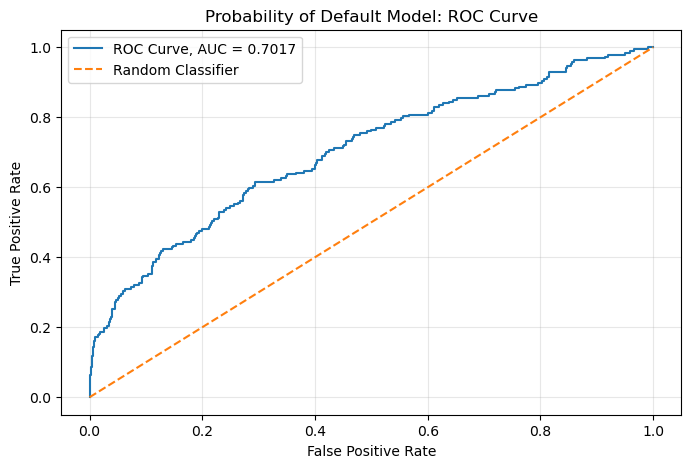

ROC curve saved to:
C:\Users\komet\Downloads\ifrs9-credit-impairment-forecasting\figures\roc_curve_pd_model.png


In [29]:
# Plot and save ROC curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC Curve, AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Probability of Default Model: ROC Curve")
plt.legend()
plt.grid(True, alpha=0.3)

roc_curve_path = os.path.join(figures_path, "roc_curve_pd_model.png")
plt.savefig(roc_curve_path, dpi=300, bbox_inches="tight")

plt.show()

print("ROC curve saved to:")
print(roc_curve_path)

In [31]:
# Estimate borrower-level probability of default

data["PD"] = pd_model.predict_proba(data[features])[:, 1]

data[[
    "customer_id",
    "risk_grade",
    "credit_score",
    "default_flag",
    "PD"
]].head()

,customer_id,risk_grade,credit_score,default_flag,PD
0,1,B - Moderate Low Risk,662.484974,0,0.082183
1,2,E - Very High Risk,461.411141,0,0.074695
2,3,D - High Risk,578.047321,0,0.043367
3,4,B - Moderate Low Risk,677.888400,0,0.013683
4,5,D - High Risk,550.001995,0,0.056326


In [33]:
# Add LGD and EAD assumptions

lgd_mapping = {
    "A - Low Risk": 0.25,
    "B - Moderate Low Risk": 0.35,
    "C - Moderate Risk": 0.45,
    "D - High Risk": 0.55,
    "E - Very High Risk": 0.65
}

data["LGD"] = data["risk_grade"].map(lgd_mapping)
data["EAD"] = data["loan_amount"]

data[[
    "customer_id",
    "risk_grade",
    "PD",
    "LGD",
    "EAD"
]].head()

,customer_id,risk_grade,PD,LGD,EAD
0,1,B - Moderate Low Risk,0.082183,0.35,181933.693144
1,2,E - Very High Risk,0.074695,0.65,150823.268162
2,3,D - High Risk,0.043367,0.55,167012.497204
3,4,B - Moderate Low Risk,0.013683,0.35,77703.235015
4,5,D - High Risk,0.056326,0.55,201096.935406


In [35]:
# Calculate expected credit loss

data["ECL"] = data["PD"] * data["LGD"] * data["EAD"]

data[[
    "customer_id",
    "risk_grade",
    "PD",
    "LGD",
    "EAD",
    "ECL"
]].head()

,customer_id,risk_grade,PD,LGD,EAD,ECL
0,1,B - Moderate Low Risk,0.082183,0.35,181933.693144,5233.149891
1,2,E - Very High Risk,0.074695,0.65,150823.268162,7322.712715
2,3,D - High Risk,0.043367,0.55,167012.497204,3983.572659
3,4,B - Moderate Low Risk,0.013683,0.35,77703.235015,372.129881
4,5,D - High Risk,0.056326,0.55,201096.935406,6229.793281


In [37]:
# Create portfolio impairment summary

total_ead = data["EAD"].sum()
total_ecl = data["ECL"].sum()
average_pd = data["PD"].mean()
average_lgd = data["LGD"].mean()
impairment_ratio = total_ecl / total_ead

impairment_summary = pd.DataFrame({
    "Metric": [
        "Total Exposure at Default",
        "Total Expected Credit Loss",
        "Average Probability of Default",
        "Average Loss Given Default",
        "Portfolio Impairment Ratio"
    ],
    "Value": [
        total_ead,
        total_ecl,
        average_pd,
        average_lgd,
        impairment_ratio
    ]
})

impairment_summary

,Metric,Value
0,Total Exposure at Default,1.202777e+09
1,Total Expected Credit Loss,3.976933e+07
2,Average Probability of Default,6.199613e-02
3,Average Loss Given Default,4.641800e-01
4,Portfolio Impairment Ratio,3.306460e-02


In [39]:
# Summarise ECL by risk grade

ecl_by_risk_grade = data.groupby("risk_grade").agg(
    number_of_accounts=("customer_id", "count"),
    total_ead=("EAD", "sum"),
    average_pd=("PD", "mean"),
    average_lgd=("LGD", "mean"),
    total_ecl=("ECL", "sum")
).reset_index()

ecl_by_risk_grade["impairment_ratio"] = (
    ecl_by_risk_grade["total_ecl"] / ecl_by_risk_grade["total_ead"]
)

ecl_by_risk_grade

,risk_grade,number_of_accounts,total_ead,average_pd,average_lgd,total_ecl,impairment_ratio
0,A - Low Risk,1055,1.284194e+08,0.043070,0.25,1.538206e+06,0.011978
1,B - Moderate Low Risk,2040,2.417277e+08,0.049400,0.35,4.619105e+06,0.019109
2,C - Moderate Risk,2906,3.476187e+08,0.059610,0.45,1.018848e+07,0.029309
3,D - High Risk,2430,2.933624e+08,0.068201,0.55,1.201481e+07,0.040956
4,E - Very High Risk,1569,1.916484e+08,0.085908,0.65,1.140873e+07,0.059530


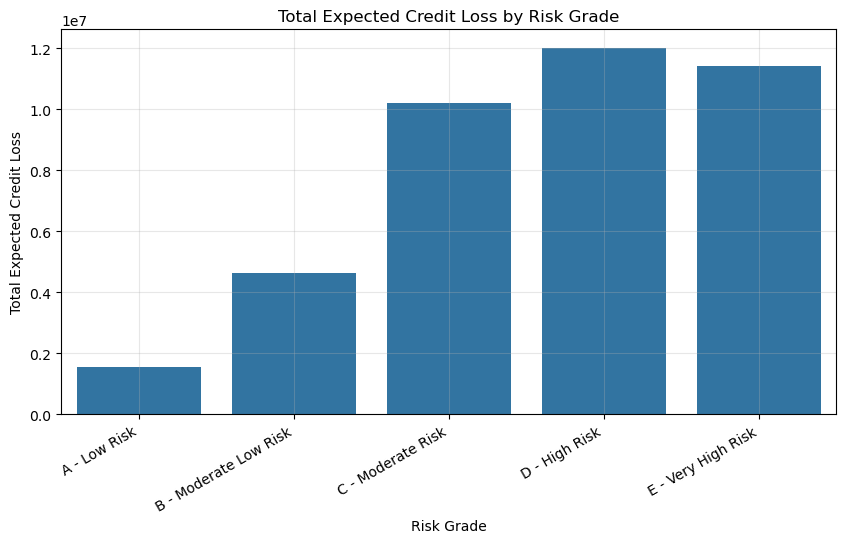

Chart saved to:
C:\Users\komet\Downloads\ifrs9-credit-impairment-forecasting\figures\total_ecl_by_risk_grade.png


In [41]:
# Plot total ECL by risk grade

plt.figure(figsize=(10, 5))
sns.barplot(
    data=ecl_by_risk_grade,
    x="risk_grade",
    y="total_ecl"
)

plt.title("Total Expected Credit Loss by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("Total Expected Credit Loss")
plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.3)

ecl_chart_path = os.path.join(figures_path, "total_ecl_by_risk_grade.png")
plt.savefig(ecl_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:")
print(ecl_chart_path)

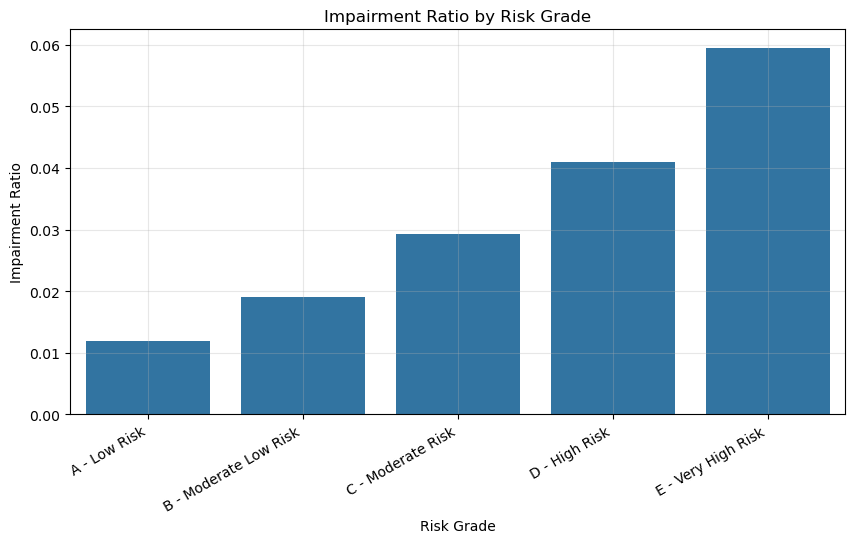

Chart saved to:
C:\Users\komet\Downloads\ifrs9-credit-impairment-forecasting\figures\impairment_ratio_by_risk_grade.png


In [43]:
# Plot impairment ratio by risk grade

plt.figure(figsize=(10, 5))
sns.barplot(
    data=ecl_by_risk_grade,
    x="risk_grade",
    y="impairment_ratio"
)

plt.title("Impairment Ratio by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("Impairment Ratio")
plt.xticks(rotation=30, ha="right")
plt.grid(True, alpha=0.3)

impairment_chart_path = os.path.join(figures_path, "impairment_ratio_by_risk_grade.png")
plt.savefig(impairment_chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:")
print(impairment_chart_path)

In [45]:
# Create model metrics table

model_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Default Threshold"
    ],
    "Value": [
        accuracy,
        roc_auc,
        0.50
    ]
})

model_metrics

,Metric,Value
0,Accuracy,0.940333
1,ROC-AUC,0.701731
2,Default Threshold,0.500000


In [47]:
# Save project outputs

data.to_csv(os.path.join(data_path, "synthetic_credit_portfolio.csv"), index=False)
model_metrics.to_csv(os.path.join(outputs_path, "model_metrics.csv"), index=False)
impairment_summary.to_csv(os.path.join(outputs_path, "impairment_summary.csv"), index=False)
ecl_by_risk_grade.to_csv(os.path.join(outputs_path, "ecl_by_risk_grade.csv"), index=False)

print("Files saved successfully.")
print(os.path.join(data_path, "synthetic_credit_portfolio.csv"))
print(os.path.join(outputs_path, "model_metrics.csv"))
print(os.path.join(outputs_path, "impairment_summary.csv"))
print(os.path.join(outputs_path, "ecl_by_risk_grade.csv"))

Files saved successfully.
C:\Users\komet\Downloads\ifrs9-credit-impairment-forecasting\data\synthetic_credit_portfolio.csv
C:\Users\komet\Downloads\ifrs9-credit-impairment-forecasting\outputs\model_metrics.csv
C:\Users\komet\Downloads\ifrs9-credit-impairment-forecasting\outputs\impairment_summary.csv
C:\Users\komet\Downloads\ifrs9-credit-impairment-forecasting\outputs\ecl_by_risk_grade.csv
